In [6]:
%pip install "numpy<2.0" "opencv-python==4.8.0.74" cellpose==3.0.10 -q
%pip install pyocclient -q

In [1]:
import owncloud, getpass

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [10]:
!nvcc --version
!nvidia-smi

/bin/bash: line 1: nvcc: command not found
/bin/bash: line 1: nvidia-smi: command not found


In [9]:
oc.upload_data()

In [2]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2

from cellpose import core, utils, io, models, metrics, train, dynamics
from glob import glob

import importlib

In [3]:
oc.upload_scripts()
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [4]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? NO


In [4]:

io.logger_setup()

model = models.CellposeModel(gpu=True, model_type="cyto3")

path = '001'
img = visualizer.load_data(path, mode='Image')

masks, flows, styles = model.eval(img, 
                                  diameter=65, 
                                  channels=[0,0],
                                  resample=True)


output_dir = './data/processed/cellpose/annotation'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks)

print(f"Masque sauvegardé : {save_path}")

Masque sauvegardé : ./data/processed/cellpose/annotation/001_Cell_pred.bmp


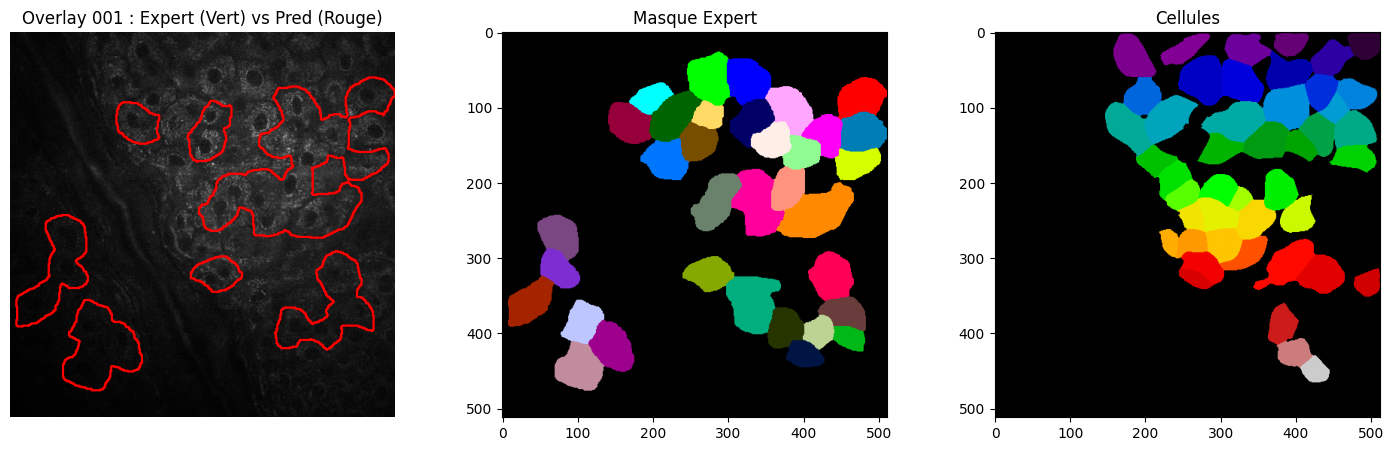

[Cellpose] F1: 0.100 | TP: 3 | FN: 12


{'f1': 0.10000000149011612,
 'ap': 0.05263157933950424,
 'tp': 3,
 'fp': 42,
 'fn': 12}

In [5]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=true_mask, ax=ax1, show=False)
visualizer.plot(data = masks, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose", true_mask, masks)


In [6]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

ids_train = ['002', '003', '004','005', '006', '007', '008', '009', '010']
ids_val   = ['011', '012', '013', '014', '015']

X_train = [visualizer.load_data(id, 'Image') for id in ids_train]
Y_train = [visualizer.load_data(id, 'Cell')[:,:,0] for id in ids_train]
X_val   = [visualizer.load_data(id, 'Image') for id in ids_val]
Y_val   = [visualizer.load_data(id, 'Cell')[:,:,0] for id in ids_val]

io.logger_setup()
model = models.CellposeModel(model_type='cyto3', gpu=False)

model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    channels=[0,0],
    n_epochs=10,          
    learning_rate=0.05,
    weight_decay=0.0001,  
    save_path='./models/',
    model_name='cyto3_pro'
)

print(f"Modèle sauvegardé : {model_path}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(test_losses, label='Test Loss (Val)', color='orange', marker='s')
plt.title(f"Apprentissage ({model_path.split('/')[-1]}) | LR={0.05}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


100%|██████████| 5/5 [00:00<00:00, 643.22it/s]


TypeError: cannot unpack non-iterable PosixPath object

In [9]:
io.logger_setup()

model = models.CellposeModel(gpu=False, pretrained_model=model_finetune)

img_id = '001'
img = visualizer.load_data(img_id, mode='Image')

masks, flows, styles = model.eval(img, 
                                  diameter=None, 
                                  channels=[0,0],
                                  resample=True)

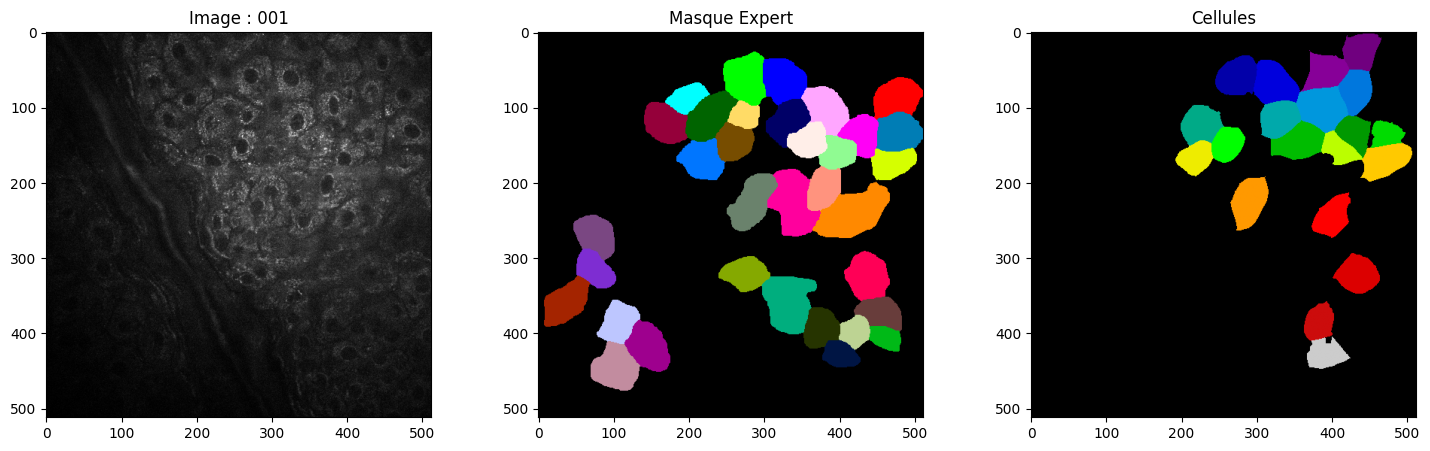

[Cellpose] F1: 0.029 | TP: 4 | FN: 251


{'f1': 0.02909090928733349,
 'ap': 0.014760147780179977,
 'tp': 4,
 'fp': 16,
 'fn': 251}

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot(i = "001", mode='Image', ax=ax1, show=False)
visualizer.plot(data = masks, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()

ev.report("Cellpose", true_mask, masks)
